# 09. Graph Discovery and Centrality

This notebook is the graph discovery deliverable for the anime recommendation project. It turns the catalog into a directed weighted graph and asks what the graph adds beyond the recommender evaluation recommender.

The connection to the previous material is explicit:

- **recommender evaluation:** a recommender must define a candidate pool, compare against baselines, and avoid claiming that examples are proof by themselves.
- **Graph modeling:** a graph is a modeling choice. Nodes, edges, weights, direction, components, transition behavior, and centrality all need interpretation.
- **graph discovery:** we use graph structure as a structural layer for discovery, entry points, franchise navigation, and guardrails around ranking.

The goal is not to replace SVD or popularity. The goal is to understand the anime network and explain how graph ranking differs from popularity or personalized model ranking.

## Graph Definition and Modeling Contract

**Node grain:** one anime catalog entry, keyed by MAL id.

**Directed recommendation edge:** `source -> target` means the target is recommended as similar to the source. The weight is the merged recommendation strength from available sources.

**Directed relation edge:** `source -> target` means MAL/AniDB relation data links the entries. These edges are not pure similarity: they often encode viewing order, franchise membership, summaries, side stories, parent stories, or alternative versions.

**Why directed?** PageRank and transition interpretation need edge orientation. A recommendation from A to B is not always symmetric, and relation direction matters when avoiding sequence mistakes like recommending season 3 before season 1.

**Why weighted?** A recommendation with many votes should carry more signal than a single weak recommendation. A sequel/parent-story relation should carry more navigation force than a loose `Other` relation.

The notebook builds three graph definitions so we can check sensitivity:

1. `recommendation`: similarity/recommendation edges only.
2. `relation`: franchise/navigation edges only.
3. `combined`: both edge families together. This is the main graph discovery graph.

In [1]:
from pathlib import Path
import json
import math
import subprocess
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
GRAPH_DIR = ROOT / 'artifacts' / 'graph'
PLOT_DIR = ROOT / 'artifacts' / 'plots' / 'graph'
CATALOG_PATH = ROOT / 'data' / 'processed' / 'anime_dataset.csv'
SCRIPT = ROOT / 'src' / '09_build_discovery_graph.py'

plt.style.use('default')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)

print(f'Project root: {ROOT}')

Project root: C:\Users\CHAMPUX\Downloads\UPC TRABAJOS 2026\BIG DATA\proyect


## Regenerate the Graph Artifacts

This cell runs the executable graph-construction script. It is intentionally streaming: if the script takes a while, the notebook prints progress/output instead of silently spinning.

In [2]:
print(f'Running {SCRIPT.relative_to(ROOT)}')
process = subprocess.Popen(
    [sys.executable, str(SCRIPT)],
    cwd=ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end='')
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f'graph discovery graph script failed with exit code {return_code}')

Running src\09_build_discovery_graph.py
{
  "graph_definition": "directed weighted anime graph with recommendation and relation edges",
  "main_graph": "combined",
  "outputs": {
    "summary": "artifacts\\graph\\graph_summary.csv",
    "combined_metrics": "artifacts\\graph\\combined_graph_metrics.csv",
    "comparison": "artifacts\\graph\\graph_ranking_comparison.csv",
    "validity_checks": "artifacts\\graph\\graph_validity_checks.csv",
    "report": "reports\\graph_discovery_report.md"
  },
  "summaries": [
    {
      "graph": "recommendation",
      "nodes": 15492,
      "edges": 181378,
      "density": 0.0007557839527788247,
      "weak_components": 3562,
      "strong_components": 4326,
      "largest_weak_component": 11829,
      "largest_weak_component_pct": 0.7635553834237025,
      "isolated_nodes": 3477,
      "isolated_pct": 0.22443841982958945,
      "mean_out_degree": 11.707849212496772,
      "mean_in_degree": 11.707849212496772
    },
    {
      "graph": "relation",


## Load Outputs and Helper Parsers

The script already saved the reproducible artifacts. The next cells load them back into the notebook so the tables and plots are visible inline.

In [3]:
catalog = pd.read_csv(CATALOG_PATH)
summary = pd.read_csv(GRAPH_DIR / 'graph_summary.csv')
comparison = pd.read_csv(GRAPH_DIR / 'graph_ranking_comparison.csv')
checks = pd.read_csv(GRAPH_DIR / 'graph_validity_checks.csv')
combined_metrics = pd.read_csv(GRAPH_DIR / 'combined_graph_metrics.csv')
recommendation_metrics = pd.read_csv(GRAPH_DIR / 'recommendation_graph_metrics.csv')
relation_metrics = pd.read_csv(GRAPH_DIR / 'relation_graph_metrics.csv')

for col in ['mal_id', 'score', 'members', 'popularity', 'favorites']:
    if col in catalog.columns:
        catalog[col] = pd.to_numeric(catalog[col], errors='coerce')

VALID_IDS = set(catalog['mal_id'].dropna().astype(int))

def parse_recommendations(value):
    out = []
    if pd.isna(value) or str(value).strip() == '':
        return out
    for item in str(value).split('|'):
        target, _, weight = item.partition(':')
        try:
            target_id = int(float(target))
            if target_id in VALID_IDS:
                out.append((target_id, float(weight or 1)))
        except ValueError:
            pass
    return out

def parse_relations(value):
    out = []
    if pd.isna(value) or str(value).strip() == '':
        return out
    for item in str(value).split('|'):
        target, _, relation = item.partition(':')
        try:
            target_id = int(float(target))
            if target_id in VALID_IDS:
                out.append((target_id, relation.strip() or 'Other'))
        except ValueError:
            pass
    return out

def pipe_count(series):
    counts = {}
    for value in series.fillna(''):
        for item in str(value).split('|'):
            item = item.strip()
            if item:
                counts[item] = counts.get(item, 0) + 1
    return pd.DataFrame({'label': list(counts), 'count': list(counts.values())}).sort_values('count', ascending=False)

print(f'Catalog rows: {len(catalog):,}')
print(f'Combined graph rows: {len(combined_metrics):,}')

Catalog rows: 15,492
Combined graph rows: 15,492


## Component and Sparsity Checks

For graph recommendation, a graph result is only meaningful after checking the edge-list contract. The first audit is structural: how many nodes and edges exist, how sparse is the graph, how many components exist, and how many nodes are isolated?

The combined graph should have fewer isolates than either single-source graph because recommendation edges connect similar entries while relation edges connect franchise paths.

,graph,nodes,edges,density,weak_components,strong_components,largest_weak_component,largest_weak_component_pct,isolated_nodes,isolated_pct,mean_out_degree,mean_in_degree
0,recommendation,15492,181378,0.000756,3562,4326,11829,0.763555,3477,0.224438,11.707849,11.707849
1,relation,15492,19196,0.000080,7541,7660,237,0.015298,5245,0.338562,1.239091,1.239091
2,combined,15492,199418,0.000831,1109,1198,14180,0.915311,967,0.062419,12.872321,12.872321


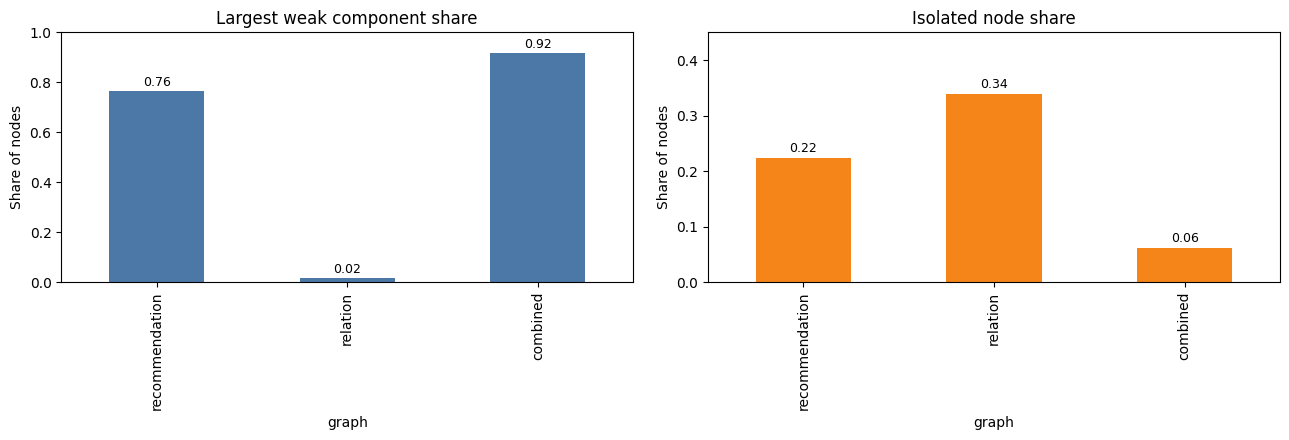

In [4]:
display(summary)

def label_bars(ax, fmt='{:.2f}'):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, fontsize=9, padding=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
summary.plot.bar(x='graph', y='largest_weak_component_pct', ax=axes[0], color='#4C78A8', legend=False)
axes[0].set_title('Largest weak component share')
axes[0].set_ylabel('Share of nodes')
axes[0].set_ylim(0, 1)
label_bars(axes[0])
summary.plot.bar(x='graph', y='isolated_pct', ax=axes[1], color='#F58518', legend=False)
axes[1].set_title('Isolated node share')
axes[1].set_ylabel('Share of nodes')
axes[1].set_ylim(0, max(0.45, summary['isolated_pct'].max() * 1.2))
label_bars(axes[1])
plt.tight_layout()
plt.show()

## Edge Source Audit

Recommendation and relation edges answer different product questions.

- Recommendation edges are mostly **similarity/discovery** evidence.
- Relation edges are mostly **navigation/order** evidence.

This matters for the recommender: a high-weight similar-anime edge can suggest a new standalone title, while a relation edge can say "this is a sequel, summary, side story, or parent story" and should be used as a guardrail.

,edge_family,edge_count,unique_sources,unique_targets
0,recommendation,181379,12012,11280
1,relation,19224,10215,10183


,relation,count
0,Sequel,3480
1,Prequel,3454
2,Other,2925
3,Parent Story,2183
4,Side Story,1944
5,Alternative Version,1530
6,Alternative Setting,1206
7,Full Story,669
8,Summary,658
9,Spin-Off,619


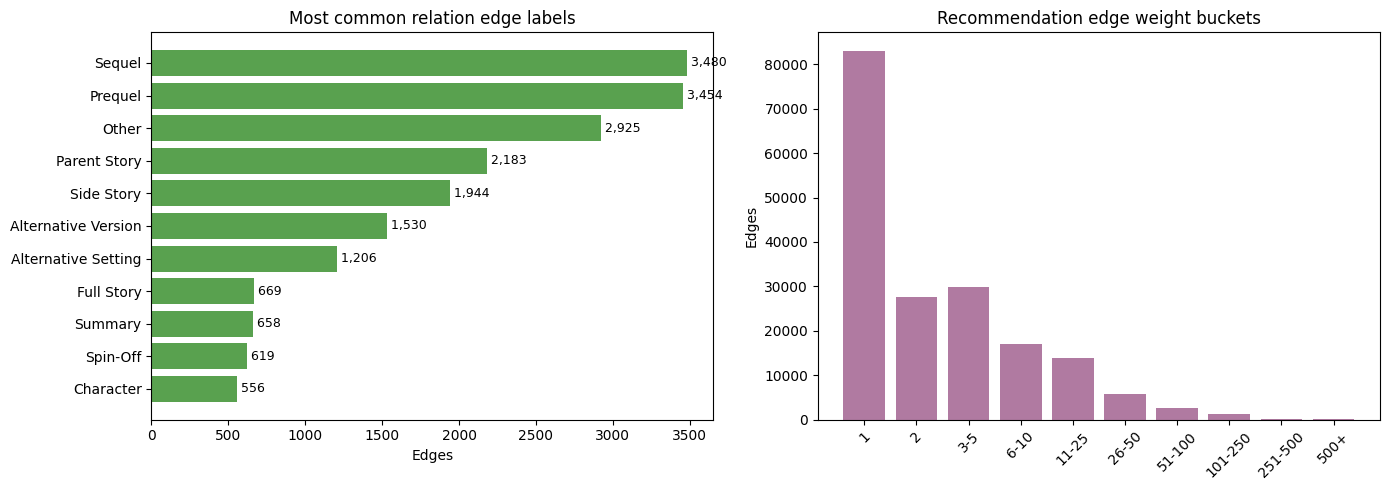

In [5]:
rec_edges = []
rel_edges = []
for row in catalog.itertuples(index=False):
    source = int(getattr(row, 'mal_id'))
    title = getattr(row, 'title')
    for target, weight in parse_recommendations(getattr(row, 'recommendations', '')):
        rec_edges.append({'source': source, 'source_title': title, 'target': target, 'weight': weight})
    for target, relation in parse_relations(getattr(row, 'relations', '')):
        rel_edges.append({'source': source, 'source_title': title, 'target': target, 'relation': relation})
rec_edges = pd.DataFrame(rec_edges)
rel_edges = pd.DataFrame(rel_edges)

edge_audit = pd.DataFrame([
    {'edge_family': 'recommendation', 'edge_count': len(rec_edges), 'unique_sources': rec_edges['source'].nunique(), 'unique_targets': rec_edges['target'].nunique()},
    {'edge_family': 'relation', 'edge_count': len(rel_edges), 'unique_sources': rel_edges['source'].nunique(), 'unique_targets': rel_edges['target'].nunique()},
])
display(edge_audit)

top_relations = rel_edges['relation'].value_counts().rename_axis('relation').reset_index(name='count') if not rel_edges.empty else pd.DataFrame()
display(top_relations.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if not top_relations.empty:
    top = top_relations.head(12).iloc[::-1]
    axes[0].barh(top['relation'], top['count'], color='#59A14F')
    axes[0].set_title('Most common relation edge labels')
    axes[0].set_xlabel('Edges')
    for y, value in enumerate(top['count']):
        axes[0].text(value, y, f' {value:,}', va='center', fontsize=9)
if not rec_edges.empty:
    bins = [0, 1, 2, 5, 10, 25, 50, 100, 250, 500, np.inf]
    labels = ['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '101-250', '251-500', '500+']
    buckets = pd.cut(rec_edges['weight'], bins=bins, labels=labels, include_lowest=True).value_counts().reindex(labels)
    axes[1].bar(buckets.index.astype(str), buckets.values, color='#B07AA1')
    axes[1].set_title('Recommendation edge weight buckets')
    axes[1].set_ylabel('Edges')
    axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Centrality: PageRank, Degree, and Weighted Degree

Centrality is not the same as quality. In this domain:

- **In-degree**: how many titles point to this anime.
- **Weighted in-degree**: how much recommendation/relation strength points to this anime.
- **PageRank**: recursive graph prestige; a title matters more when important titles point to it.
- **Hub score**: titles that point outward to important authorities.
- **Authority score**: titles that receive links from good hubs.

This is graph ranking, not personalized recommendation. It is useful for global entry points, franchise hubs, and structural guardrails.

,mal_id,title,type,pagerank,weighted_in_degree,in_degree,out_degree,members,score,genres
0,11061,Hunter x Hunter (2011),TV,0.002340,8221.0,256,183,3205575,9.03,Action|Adventure|Fantasy
1,30,Shinseiki Evangelion,TV,0.002215,4157.0,394,314,2039711,8.37,Action|Drama|Mecha|Mystery|Psychological|Sci-Fi
2,40748,Jujutsu Kaisen,TV,0.002207,5880.0,138,96,3061150,8.50,Action|Drama|Supernatural
3,1535,Death Note,TV,0.002060,6929.0,273,238,4319618,8.62,Mystery|Psychological|Supernatural|Thriller
4,28851,Koe no Katachi,Movie,0.002006,8218.0,140,95,2630893,8.93,Drama|Romance|Slice of Life
5,38000,Kimetsu no Yaiba,TV,0.001998,4898.0,217,123,3467951,8.40,Action|Adventure|Drama|Fantasy|Supernatural
6,32281,Kimi no Na wa.,Movie,0.001904,8159.0,138,110,3040773,8.82,Drama|Romance|Supernatural
7,21,One Piece,TV,0.001900,4026.0,269,218,2701642,8.73,Action|Adventure|Comedy|Drama|Fantasy
8,2001,Tengen Toppa Gurren Lagann,TV,0.001890,3809.0,310,247,1775700,8.64,Action|Comedy|Drama|Mecha|Romance|Sci-Fi
9,9756,Mahou Shoujo Madoka★Magica,TV,0.001801,4073.0,362,300,1417676,8.39,Action|Drama|Fantasy|Mahou Shoujo|Psychological|Thriller


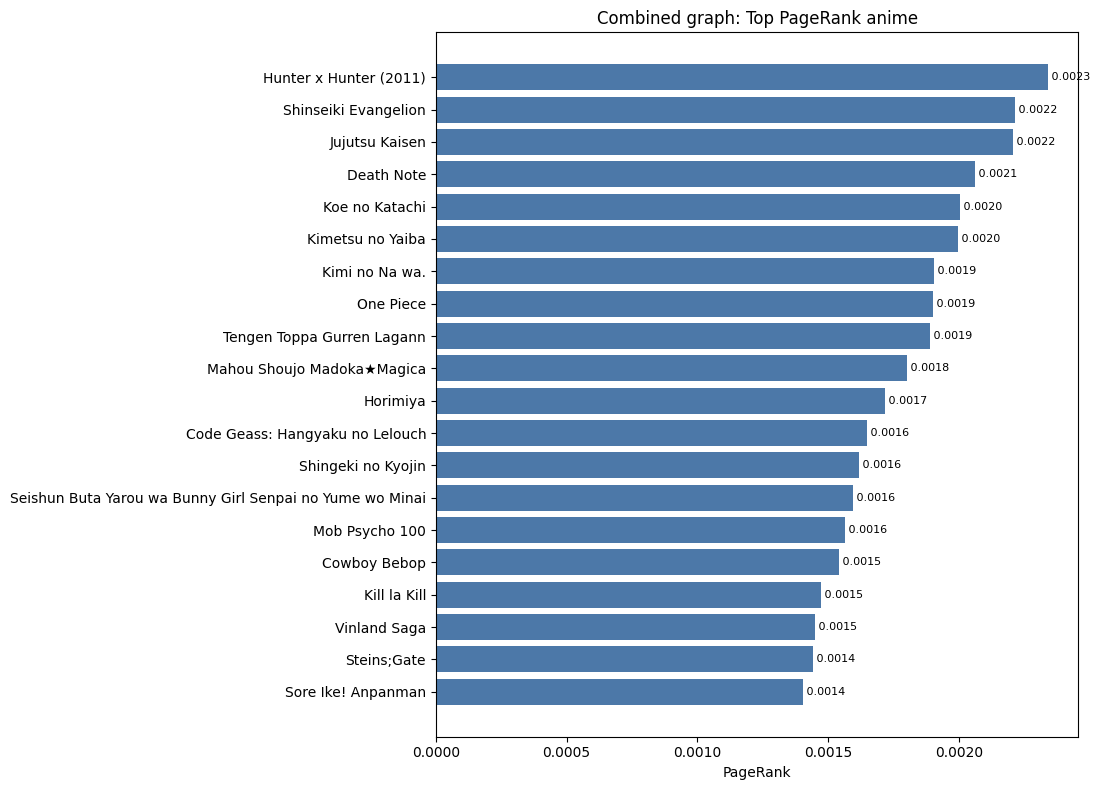

In [6]:
top_cols = ['mal_id', 'title', 'type', 'pagerank', 'weighted_in_degree', 'in_degree', 'out_degree', 'members', 'score', 'genres']
display(combined_metrics[top_cols].head(25))

fig, ax = plt.subplots(figsize=(11, 8))
top = combined_metrics.head(20).iloc[::-1]
bars = ax.barh(top['title'], top['pagerank'], color='#4C78A8')
ax.set_title('Combined graph: Top PageRank anime')
ax.set_xlabel('PageRank')
for bar in bars:
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {bar.get_width():.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Degree Distributions and Local Hubs

Graph degree distributions are usually skewed. A few anime receive many links and many entries receive few or none. This is why the notebook reports both centrality and validity checks instead of only showing a pretty graph.

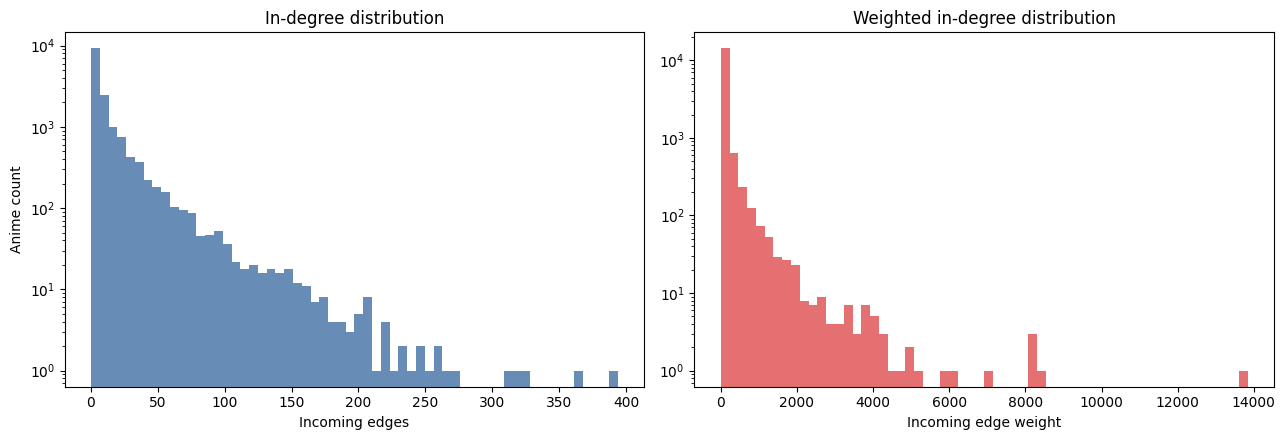

,mal_id,title,type,pagerank,weighted_in_degree,in_degree,out_degree,members,score,genres
61,6702,Fairy Tail,TV,0.000888,13841.0,181,116,1850480,7.57,Action|Adventure|Comedy|Fantasy
175,136,Hunter x Hunter,TV,0.000523,8527.0,128,75,651157,8.44,Action|Adventure|Fantasy
0,11061,Hunter x Hunter (2011),TV,0.002340,8221.0,256,183,3205575,9.03,Action|Adventure|Fantasy
4,28851,Koe no Katachi,Movie,0.002006,8218.0,140,95,2630893,8.93,Drama|Romance|Slice of Life
6,32281,Kimi no Na wa.,Movie,0.001904,8159.0,138,110,3040773,8.82,Drama|Romance|Supernatural
3,1535,Death Note,TV,0.002060,6929.0,273,238,4319618,8.62,Mystery|Psychological|Supernatural|Thriller
10,42897,Horimiya,TV,0.001717,6084.0,150,100,1655204,8.18,Comedy|Romance|Slice of Life
2,40748,Jujutsu Kaisen,TV,0.002207,5880.0,138,96,3061150,8.50,Action|Drama|Supernatural
13,37450,Seishun Buta Yarou wa Bunny Girl Senpai no Yume wo Minai,TV,0.001594,5238.0,162,111,1971676,8.23,Comedy|Drama|Mystery|Psychological|Romance|Supernatural
5,38000,Kimetsu no Yaiba,TV,0.001998,4898.0,217,123,3467951,8.40,Action|Adventure|Drama|Fantasy|Supernatural


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(combined_metrics['in_degree'], bins=60, color='#4C78A8', alpha=0.85)
axes[0].set_title('In-degree distribution')
axes[0].set_xlabel('Incoming edges')
axes[0].set_ylabel('Anime count')
axes[0].set_yscale('log')
axes[1].hist(combined_metrics['weighted_in_degree'], bins=60, color='#E15759', alpha=0.85)
axes[1].set_title('Weighted in-degree distribution')
axes[1].set_xlabel('Incoming edge weight')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

degree_rank = combined_metrics.sort_values('weighted_in_degree', ascending=False)[top_cols].head(20)
display(degree_rank)

## Graph Ranking Compared With Popularity and Model Ranking

graph discovery requires a comparison against non-graph ranking. The graph report compares PageRank with MAL popularity (`members`), MAL score, weighted incoming edge strength, and the recommender evaluation personalized MyList hybrid example when that artifact exists.

The most important interpretation is not "which number is highest?" It is whether the graph is measuring a different thing. A moderate correlation with popularity is expected, but a perfect correlation would mean the graph adds little beyond member count.

,comparison,metric,value,interpretation
0,combined_pagerank_vs_members,spearman,0.460620,Graph prestige compared with MAL popularity.
1,combined_pagerank_vs_score,spearman,0.380006,Graph prestige compared with average catalog score.
2,combined_pagerank_vs_weighted_in_degree,spearman,0.828765,PageRank compared with direct incoming recommendation weight.


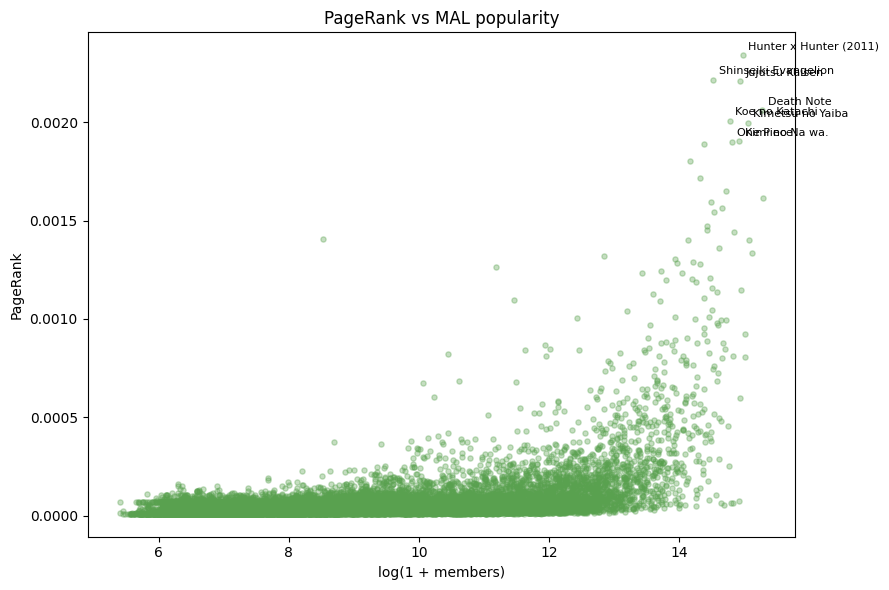

Graph-over-indexed titles: high PageRank relative to MAL members


,mal_id,title,type,pagerank_rank,members_rank,pagerank,members,score,graph_over_popularity_gap
1054,30150,Kamiusagi Rope 3,Movie,1055.0,14950.0,0.000162,542,5.47,13895.0
1154,32820,Xiong Chumo: Chunri Dui Dui Peng,TV,1155.0,14963.0,0.000154,538,5.63,13808.0
1722,36678,Kawawawawawada,Special,1723.0,15419.0,0.000111,336,4.83,13696.0
1185,30753,Himitsukessha Taka no Tsume The Movie 4: Kaspersky wo Motsu Otoko,OVA,1186.0,14813.0,0.000150,578,5.64,13627.0
1323,13819,Kamiusagi Rope 2,Movie,1324.0,14905.0,0.000137,554,5.65,13581.0
1621,32818,Xiong Chumo: Huanqiu Da Maoxian,TV,1622.0,15100.0,0.000116,491,5.69,13478.0
1843,19069,Okane wa Mawaru: Kurashi to Kinyuu,OVA,1832.0,15294.0,0.000106,415,5.75,13462.0
1358,33194,Shi Wan Ge Leng Xiaohua 2nd Season,ONA,1359.0,14783.0,0.000133,588,5.99,13424.0
1847,38535,Huoli Shaonian Wang 3: Xuji,TV,1832.0,15226.0,0.000106,447,6.27,13394.0
1837,9818,McDull: Boluo You Wang Zi,Movie,1832.0,15224.0,0.000106,448,6.38,13392.0


Popularity-over-indexed titles: high MAL members relative to PageRank


,mal_id,title,type,pagerank_rank,members_rank,pagerank,members,score,popularity_over_graph_gap
13796,9062,Angel Beats! Specials,Special,13796.0,996.0,0.000012,283038,7.55,12800.0
13795,10067,Angel Beats! Another Epilogue,Special,13796.0,1132.0,0.000012,252310,7.44,12664.0
13276,34626,Kono Subarashii Sekai ni Shukufuku wo! 2: Kono Subarashii Geijutsu ni Shukufuku wo!,OVA,13277.0,668.0,0.000014,409768,8.01,12609.0
13293,38414,Re:Zero kara Hajimeru Isekai Seikatsu - Hyouketsu no Kizuna,Movie,13294.0,864.0,0.000013,327835,7.58,12430.0
14216,39607,Tensei shitara Slime Datta Ken: Kanwa - Veldora Nikki,Special,14217.0,1849.0,0.000011,143092,6.79,12368.0
13608,30347,Nanatsu no Taizai OVA,OVA,13609.0,1414.0,0.000013,199454,7.47,12195.0
13990,27891,Sword Art Online II: Debriefing,Special,13991.0,1864.0,0.000012,141978,6.72,12127.0
13083,32188,Steins;Gate: Kyoukaimenjou no Missing Link - Divide By Zero,Special,13084.0,970.0,0.000014,291518,8.27,12114.0
13494,5204,Kara no Kyoukai Movie 6: Boukyaku Rokuon,Movie,13495.0,1383.0,0.000013,204257,7.43,12112.0
13581,33071,Bungou Stray Dogs: Hitori Ayumu,OVA,13582.0,1489.0,0.000013,187650,7.66,12093.0


In [8]:
display(comparison)

plot_df = combined_metrics.copy()
plot_df['members_log'] = np.log1p(pd.to_numeric(plot_df['members'], errors='coerce').fillna(0))
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_df['members_log'], plot_df['pagerank'], s=14, alpha=0.35, color='#59A14F')
ax.set_title('PageRank vs MAL popularity')
ax.set_xlabel('log(1 + members)')
ax.set_ylabel('PageRank')
for _, row in plot_df.nlargest(8, 'pagerank').iterrows():
    ax.annotate(str(row['title'])[:24], (row['members_log'], row['pagerank']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

rank_compare = combined_metrics.copy()
rank_compare['members_rank'] = rank_compare['members'].rank(ascending=False, method='min')
rank_compare['pagerank_rank'] = rank_compare['pagerank'].rank(ascending=False, method='min')
rank_compare['graph_over_popularity_gap'] = rank_compare['members_rank'] - rank_compare['pagerank_rank']
rank_compare['popularity_over_graph_gap'] = rank_compare['pagerank_rank'] - rank_compare['members_rank']
print('Graph-over-indexed titles: high PageRank relative to MAL members')
display(rank_compare.sort_values('graph_over_popularity_gap', ascending=False)[['mal_id','title','type','pagerank_rank','members_rank','pagerank','members','score','graph_over_popularity_gap']].head(15))
print('Popularity-over-indexed titles: high MAL members relative to PageRank')
display(rank_compare.sort_values('popularity_over_graph_gap', ascending=False)[['mal_id','title','type','pagerank_rank','members_rank','pagerank','members','score','popularity_over_graph_gap']].head(15))

## Random-Walk Interpretation: One-Step Navigation

For graph recommendation, a transition matrix needs interpretation. Here, a one-step transition from a seed anime means: "if I follow one outgoing weighted graph edge, which targets receive the most probability?"

This is not proof of viewing order or personal preference. It is a local navigation diagnostic.

Seed: 5081 - Bakemonogatari


,target,target_title,edge_family,edge_label,weight,probability
154,37450,Seishun Buta Yarou wa Bunny Girl Senpai no Yume wo Minai,recommendation,recommendation,651.0,0.241738
172,50346,Yofukashi no Uta,recommendation,recommendation,190.0,0.070553
56,6594,Katanagatari,recommendation,recommendation,182.0,0.067583
66,7785,Yojouhan Shinwa Taikei,recommendation,recommendation,173.0,0.064241
141,33263,Kubikiri Cycle: Aoiro Savant to Zaregotozukai,recommendation,recommendation,107.0,0.039733
32,2605,Sayonara Zetsubou Sensei,recommendation,recommendation,102.0,0.037876
15,849,Suzumiya Haruhi no Yuuutsu,recommendation,recommendation,82.0,0.030449
63,7647,Arakawa Under the Bridge,recommendation,recommendation,80.0,0.029707
74,9756,Mahou Shoujo Madoka★Magica,recommendation,recommendation,80.0,0.029707
162,40752,Bishounen Tanteidan,recommendation,recommendation,71.0,0.026365


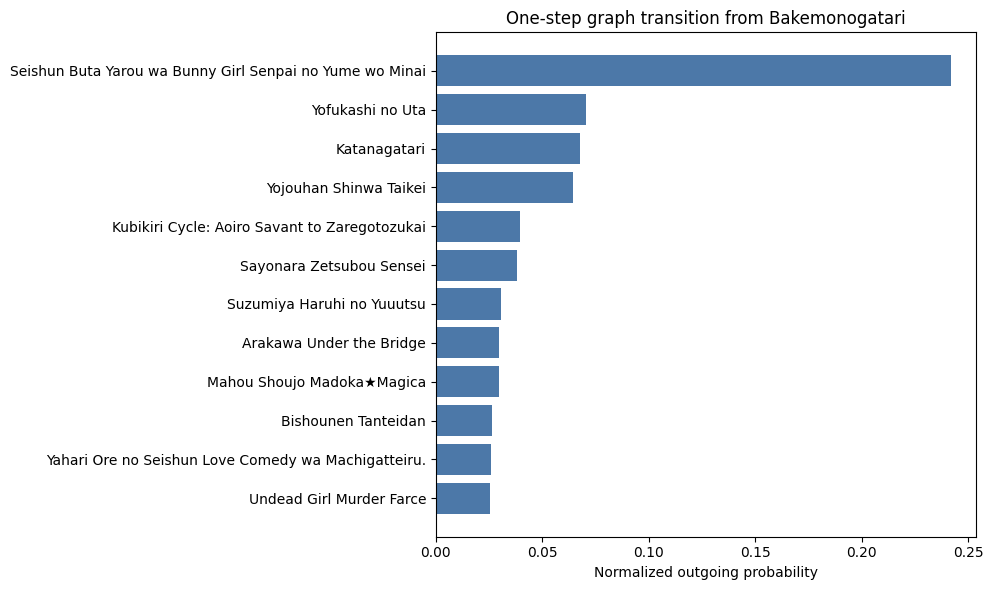

In [9]:
def local_neighbors(seed_id, top_n=15):
    rows = []
    source = catalog[catalog['mal_id'].eq(seed_id)]
    if source.empty:
        return pd.DataFrame()
    source_row = source.iloc[0]
    for target, weight in parse_recommendations(source_row.get('recommendations', '')):
        rows.append({'target': target, 'edge_family': 'recommendation', 'edge_label': 'recommendation', 'weight': weight})
    for target, relation in parse_relations(source_row.get('relations', '')):
        relation_weight = {'Sequel': 10, 'Prequel': 10, 'Parent Story': 9, 'Full Story': 9, 'Side Story': 6, 'Alternative Version': 5, 'Alternative Setting': 5, 'Summary': 3, 'Other': 2}.get(relation, 2)
        rows.append({'target': target, 'edge_family': 'relation', 'edge_label': relation, 'weight': relation_weight})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    titles = catalog.set_index('mal_id')['title'].to_dict()
    out = out.groupby(['target','edge_family','edge_label'], as_index=False)['weight'].sum()
    out['probability'] = out['weight'] / out['weight'].sum()
    out['target_title'] = out['target'].map(titles)
    return out.sort_values('probability', ascending=False).head(top_n)

seed_id = 5081  # Bakemonogatari
seed_title = catalog.loc[catalog['mal_id'].eq(seed_id), 'title'].iloc[0] if seed_id in VALID_IDS else 'seed missing'
print(f'Seed: {seed_id} - {seed_title}')
neighbors = local_neighbors(seed_id, top_n=20)
display(neighbors[['target','target_title','edge_family','edge_label','weight','probability']])

if not neighbors.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    top = neighbors.head(12).iloc[::-1]
    colors = np.where(top['edge_family'].eq('relation'), '#F58518', '#4C78A8')
    ax.barh(top['target_title'], top['probability'], color=colors)
    ax.set_title(f'One-step graph transition from {seed_title}')
    ax.set_xlabel('Normalized outgoing probability')
    plt.tight_layout()
    plt.show()

## Visual Ego Graph: A Franchise/Neighborhood Example

A full graph with ~15k nodes is unreadable. For visual inspection, we draw a small ego graph around one seed. This is diagnostic only. It helps explain edge direction, labels, and why graph guardrails matter for franchise-heavy anime.

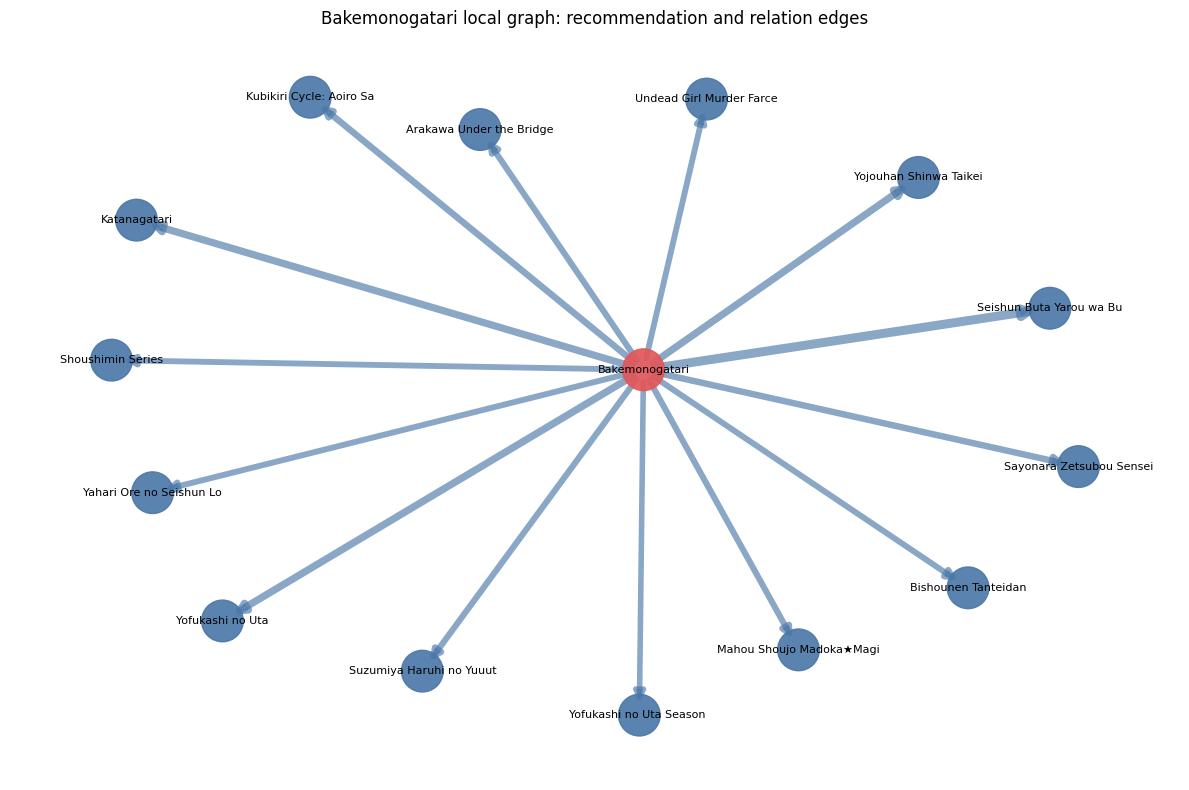

In [10]:
def build_small_graph(seed_id, max_neighbors=14):
    G = nx.DiGraph()
    title_lookup = catalog.set_index('mal_id')['title'].to_dict()
    G.add_node(seed_id, label=str(title_lookup.get(seed_id, seed_id))[:24], kind='seed')
    local = local_neighbors(seed_id, top_n=max_neighbors)
    for row in local.itertuples(index=False):
        G.add_node(int(row.target), label=str(row.target_title)[:24], kind=row.edge_family)
        G.add_edge(seed_id, int(row.target), weight=float(row.weight), label=str(row.edge_label), kind=row.edge_family)
    return G

G_small = build_small_graph(5081, max_neighbors=14)
if len(G_small) > 1:
    pos = nx.spring_layout(G_small, seed=42, k=0.9)
    node_colors = ['#E15759' if data.get('kind') == 'seed' else '#F58518' if data.get('kind') == 'relation' else '#4C78A8' for _, data in G_small.nodes(data=True)]
    edge_colors = ['#F58518' if data.get('kind') == 'relation' else '#4C78A8' for _, _, data in G_small.edges(data=True)]
    widths = [max(1, math.log1p(data.get('weight', 1))) for _, _, data in G_small.edges(data=True)]
    labels = nx.get_node_attributes(G_small, 'label')
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw_networkx_nodes(G_small, pos, node_color=node_colors, node_size=900, alpha=0.92, ax=ax)
    nx.draw_networkx_edges(G_small, pos, edge_color=edge_colors, width=widths, arrows=True, arrowstyle='-|>', arrowsize=14, alpha=0.65, ax=ax)
    nx.draw_networkx_labels(G_small, pos, labels=labels, font_size=8, ax=ax)
    ax.set_title('Bakemonogatari local graph: recommendation and relation edges')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No local graph available for this seed.')

## Communities and Components: What Clusters Mean Here

A component is a navigable part of the graph. It is not the same as a genre cluster. The combined graph has a large weak component because recommendations connect many otherwise separate franchises. The relation-only graph fragments heavily because relation edges mostly stay inside franchise islands.

For a usable recommender, this distinction matters:

- **Large connected areas:** graph-aware exploration is possible.
- **Small relation components:** useful for franchise ordering.
- **Isolated nodes:** need content/popularity fallback; graph centrality cannot help much.

,component_size
0,14180
1,11
2,8
3,6
4,5
5,5
6,5
7,5
8,4
9,4


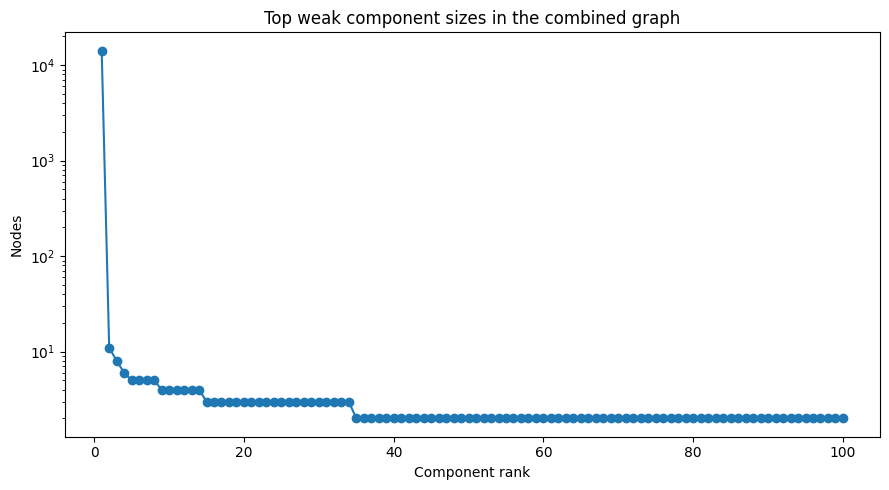

,community,nodes,top_genres,central_examples
0,1,171,"Fantasy (122), Comedy (107), Action (89), Adventure (66), Romance (66)",Tensei shitara Slime Datta Ken | Kono Subarashii Sekai ni Shukufuku wo! | Overlord | High School DxD | Tate no Yuush...
1,2,165,"Fantasy (89), Drama (81), Action (72), Mahou Shoujo (54), Comedy (48)",Mahou Shoujo Madoka★Magica | Steins;Gate | Made in Abyss | Shoujo Kakumei Utena | Re:Zero kara Hajimeru Isekai Seikatsu
2,3,162,"Sci-Fi (109), Action (85), Drama (80), Mecha (69), Adventure (52)",Shinseiki Evangelion | Tengen Toppa Gurren Lagann | Kill la Kill | Serial Experiments Lain | FLCL
3,4,139,"Romance (114), Comedy (110), Slice of Life (92), Drama (55), Supernatural (19)",Horimiya | Seishun Buta Yarou wa Bunny Girl Senpai no Yume wo Minai | Bakemonogatari | Kaguya-sama wa Kokurasetai: T...
4,5,132,"Action (118), Adventure (74), Drama (61), Supernatural (58), Fantasy (57)",Hunter x Hunter (2011) | Jujutsu Kaisen | Kimetsu no Yaiba | One Piece | Shingeki no Kyojin
5,6,127,"Drama (101), Romance (62), Fantasy (59), Slice of Life (56), Adventure (43)",Koe no Katachi | Kimi no Na wa. | Sousou no Frieren | Violet Evergarden | Kimi no Suizou wo Tabetai
6,7,113,"Action (67), Drama (59), Mystery (46), Sci-Fi (38), Psychological (36)",Death Note | Code Geass: Hangyaku no Lelouch | Cowboy Bebop | Meitantei Conan | Samurai Champloo
7,8,107,"Comedy (102), Slice of Life (54), Action (20), Supernatural (16), Drama (14)",Mob Psycho 100 | One Punch Man | Gintama | Saiki Kusuo no Ψ-nan | Nichijou
8,9,96,"Hentai (96), Romance (19), Fantasy (9), Supernatural (7), Action (5)",Overflow | Ane wa Yanmama Junyuu-chuu | Shoujo Ramune | Uchi no Otouto Maji de Dekain Dakedo Mi ni Konai? | Imaizumi...
9,10,90,"Slice of Life (73), Comedy (49), Music (30), Drama (24), Sci-Fi (12)",K-On! | Bocchi the Rock! | Yuru Camp△ | Sora yori mo Tooi Basho | Non Non Biyori


In [11]:
# Build a lightweight combined graph again for component-size and community diagnostics.
G = nx.DiGraph()
for row in catalog.itertuples(index=False):
    G.add_node(int(getattr(row, 'mal_id')), title=getattr(row, 'title'))
for row in catalog.itertuples(index=False):
    source = int(getattr(row, 'mal_id'))
    for target, weight in parse_recommendations(getattr(row, 'recommendations', '')):
        if source != target:
            G.add_edge(source, target, weight=float(weight), kind='recommendation')
    for target, relation in parse_relations(getattr(row, 'relations', '')):
        if source != target:
            w = {'Sequel': 10, 'Prequel': 10, 'Parent Story': 9, 'Full Story': 9, 'Side Story': 6, 'Alternative Version': 5, 'Alternative Setting': 5, 'Summary': 3, 'Other': 2}.get(relation, 2)
            if G.has_edge(source, target):
                G[source][target]['weight'] += w
                G[source][target]['kind'] = 'combined'
            else:
                G.add_edge(source, target, weight=w, kind='relation')

component_sizes = pd.Series([len(c) for c in nx.weakly_connected_components(G)]).sort_values(ascending=False).reset_index(drop=True)
display(component_sizes.head(20).rename('component_size').to_frame())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, min(100, len(component_sizes)) + 1), component_sizes.head(100), marker='o', linewidth=1.5)
ax.set_title('Top weak component sizes in the combined graph')
ax.set_xlabel('Component rank')
ax.set_ylabel('Nodes')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Community detection on the largest weak component, restricted for readability.
largest_nodes = max(nx.weakly_connected_components(G), key=len)
sub_nodes = set(combined_metrics[combined_metrics['mal_id'].isin(largest_nodes)].head(1500)['mal_id'].astype(int))
UG = G.subgraph(sub_nodes).to_undirected()
communities = list(nx.algorithms.community.greedy_modularity_communities(UG, weight='weight')) if UG.number_of_edges() else []
community_rows = []
title_lookup = catalog.set_index('mal_id')['title'].to_dict()
genre_lookup = catalog.set_index('mal_id')['genres'].fillna('').to_dict()
for idx, community in enumerate(communities[:12], start=1):
    nodes = list(community)
    top_titles = [title_lookup.get(node, str(node)) for node in sorted(nodes, key=lambda n: combined_metrics.set_index('mal_id')['pagerank'].get(n, 0), reverse=True)[:5]]
    genre_counts = {}
    for node in nodes:
        for genre in str(genre_lookup.get(node, '')).split('|'):
            genre = genre.strip()
            if genre:
                genre_counts[genre] = genre_counts.get(genre, 0) + 1
    top_genres = ', '.join(f'{k} ({v})' for k, v in sorted(genre_counts.items(), key=lambda kv: kv[1], reverse=True)[:5])
    community_rows.append({'community': idx, 'nodes': len(nodes), 'top_genres': top_genres, 'central_examples': ' | '.join(top_titles)})
community_df = pd.DataFrame(community_rows)
display(community_df)

## Validity Checks and Interpretation Limits

These checks are the graph equivalent of the recommender evaluation evaluation contract. They prevent overclaiming.

A graph ranking can tell us structural importance, navigability, and relation-aware risk. It cannot by itself tell us whether a specific user will like an anime. That is why the final product should combine:

- popularity and score for cold-start safety;
- collaborative SVD/hybrid ranking for personalized taste;
- graph structure for relation order, centrality, and discovery paths;
- user controls for genre, content rating, explicit content, runtime, and recency.

,check,value,status,interpretation
0,combined_graph_has_edges,199418,pass,"The graph should encode real recommendation/relation structure, not just isolated catalog rows."
1,largest_component_share,0.9153111283242964,inspect,Large component means many titles are navigable; isolated nodes remain cold-start content.
2,isolated_node_share,0.062419313193906534,inspect,High isolation limits graph recommendations for obscure entries.
3,edge_type_balance,181378 recommendation edges; 19196 relation edges,inspect,Recommendation edges measure similarity; relation edges measure franchise/navigation paths.
4,definition_sensitivity_top50_overlap,0.7857142857142857,inspect,Overlap between recommendation-only and combined PageRank shows sensitivity to graph definition.


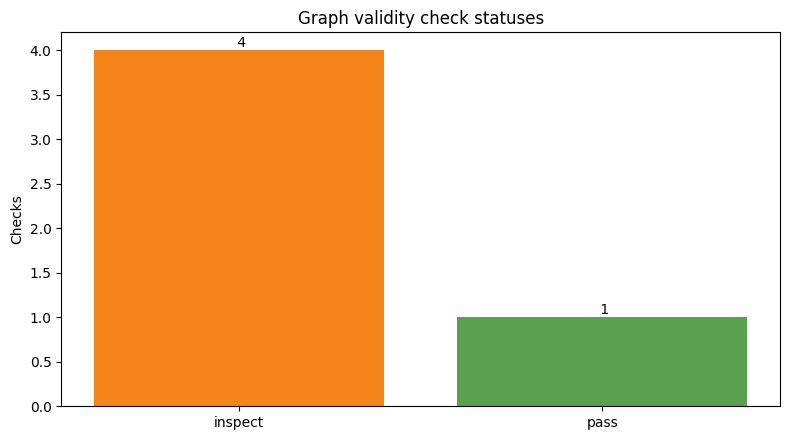

In [12]:
display(checks)

fig, ax = plt.subplots(figsize=(8, 4.5))
status_counts = checks['status'].value_counts()
ax.bar(status_counts.index, status_counts.values, color=['#59A14F' if x == 'pass' else '#F58518' for x in status_counts.index])
ax.set_title('Graph validity check statuses')
ax.set_ylabel('Checks')
for i, value in enumerate(status_counts.values):
    ax.text(i, value, f' {value}', ha='center', va='bottom')
plt.tight_layout()
plt.show()